In [34]:
import pandas as pd

df = pd.read_csv("Downloads/bengaluru_house_prices.csv")

df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [35]:
df.shape

(13320, 9)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [37]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [38]:
df.isnull().mean() * 100

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

In [39]:
# 1. Drop society because too many missing values and usually not very useful
df = df.drop('society', axis=1)

# 2. Drop rows where important columns are missing
df = df.dropna(subset=['location', 'size', 'bath'])

# 3. Fill balcony missing values
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

In [40]:
df['bhk'] = df['size'].apply(lambda x: int(x.split()[0]))

df = df.drop('size', axis=1)

In [41]:
df['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      shape=(2067,), dtype=object)

In [42]:
def convert_sqft(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df = df.dropna(subset=['total_sqft'])

In [43]:
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

In [44]:
df.describe()

,total_sqft,bath,balcony,price,bhk,price_per_sqft
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,1.320000e+04
mean,1555.302783,2.691136,1.602348,112.276178,2.800833,7.920759e+03
std,1237.323445,1.338915,0.804268,149.175995,1.292843,1.067272e+05
min,1.000000,1.000000,0.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,1.000000,50.000000,2.000000,4.267701e+03
50%,1275.000000,2.000000,2.000000,71.850000,3.000000,5.438331e+03
75%,1672.000000,3.000000,2.000000,120.000000,3.000000,7.317073e+03
max,52272.000000,40.000000,3.000000,3600.000000,43.000000,1.200000e+07


In [45]:
# Very small sqft per BHK is suspicious
df[df['total_sqft'] / df['bhk'] < 300]

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
9,Plot Area,Ready To Move,Gandhi Bazar,1020.0,6.0,2.0,370.0,6,36274.509804
45,Plot Area,Ready To Move,HSR Layout,600.0,9.0,2.0,200.0,8,33333.333333
58,Plot Area,Ready To Move,Murugeshpalya,1407.0,4.0,1.0,150.0,6,10660.980810
68,Plot Area,Ready To Move,Devarachikkanahalli,1350.0,7.0,0.0,85.0,8,6296.296296
70,Plot Area,Ready To Move,Double Road,500.0,3.0,2.0,100.0,3,20000.000000
...,...,...,...,...,...,...,...,...,...
13277,Plot Area,Ready To Move,Kundalahalli Colony,1400.0,7.0,2.0,218.0,7,15571.428571
13279,Plot Area,Ready To Move,Vishwanatha Nagenahalli,1200.0,5.0,2.0,130.0,6,10833.333333
13281,Plot Area,Ready To Move,Margondanahalli,1375.0,5.0,1.0,125.0,5,9090.909091
13303,Plot Area,Ready To Move,Vidyaranyapura,774.0,5.0,3.0,70.0,5,9043.927649


In [46]:
df = df[~(df['total_sqft'] / df['bhk'] < 300)]

In [47]:
df['location'] = df['location'].apply(lambda x: x.strip())

location_counts = df['location'].value_counts()
location_counts

location
Whitefield                        532
Sarjapur  Road                    388
Electronic City                   295
Kanakpura Road                    262
Thanisandra                       234
                                 ... 
asha township, off hennur road      1
Escorts Colony                      1
Rahat Bagh                          1
Rajanna Layout                      1
Abshot Layout                       1
Name: count, Length: 1205, dtype: int64

In [48]:
rare_locations = location_counts[location_counts <= 10].index

df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)

In [49]:
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 12456 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_type       12456 non-null  object 
 1   availability    12456 non-null  object 
 2   location        12456 non-null  object 
 3   total_sqft      12456 non-null  float64
 4   bath            12456 non-null  float64
 5   balcony         12456 non-null  float64
 6   price           12456 non-null  float64
 7   bhk             12456 non-null  int64  
 8   price_per_sqft  12456 non-null  float64
dtypes: float64(5), int64(1), object(3)
memory usage: 973.1+ KB


area_type         0
availability      0
location          0
total_sqft        0
bath              0
balcony           0
price             0
bhk               0
price_per_sqft    0
dtype: int64

In [50]:
df.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,62.00,3,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,51.00,2,4250.000000


In [51]:
df.shape

(12456, 9)

In [52]:
# Random sample records
df.sample(10)

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
6572,Super built-up Area,Ready To Move,Kambipura,883.0,2.0,1.0,44.00,2,4983.012458
921,Super built-up Area,Ready To Move,Kambipura,1082.0,2.0,1.0,57.50,3,5314.232902
2989,Super built-up Area,Ready To Move,Yelahanka,1180.0,2.0,3.0,42.00,2,3559.322034
7637,Built-up Area,Ready To Move,Kengeri,1230.0,2.0,2.0,52.00,3,4227.642276
7807,Built-up Area,Ready To Move,Kaggadasapura,1240.0,2.0,1.0,58.58,2,4724.193548
8705,Super built-up Area,18-Oct,Rayasandra,1708.0,3.0,1.0,76.00,4,4449.648712
1597,Super built-up Area,Ready To Move,Hebbal,2483.0,5.0,2.0,215.00,4,8658.880387
10697,Super built-up Area,Ready To Move,Bellandur,3596.0,4.0,2.0,359.00,4,9983.314794
4133,Super built-up Area,Ready To Move,HSR Layout,1600.0,2.0,2.0,115.00,3,7187.500000
7325,Plot Area,18-May,Sarjapur Road,1200.0,3.0,2.0,70.00,3,5833.333333


In [53]:
# Numeric features
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
numeric_features

Index(['total_sqft', 'bath', 'balcony', 'price', 'bhk', 'price_per_sqft'], dtype='object')

In [54]:
# Categorical features
categorical_features = df.select_dtypes(include=['object']).columns
categorical_features

Index(['area_type', 'availability', 'location'], dtype='object')

In [55]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numeric features:", list(numeric_features))
print("Categorical features:", list(categorical_features))

Numeric features: ['total_sqft', 'bath', 'balcony', 'price', 'bhk', 'price_per_sqft']
Categorical features: ['area_type', 'availability', 'location']


In [56]:
df['location'] = df['location'].apply(lambda x: x.strip())

location_counts = df['location'].value_counts()
rare_locations = location_counts[location_counts <= 10].index

df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)

In [57]:
df_encoded = pd.get_dummies(
    df,
    columns=['area_type', 'availability', 'location'],
    drop_first=True
)

In [58]:
X = df_encoded.drop(['price', 'price_per_sqft'], axis=1)
y = df_encoded['price']

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.5528663122173307

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

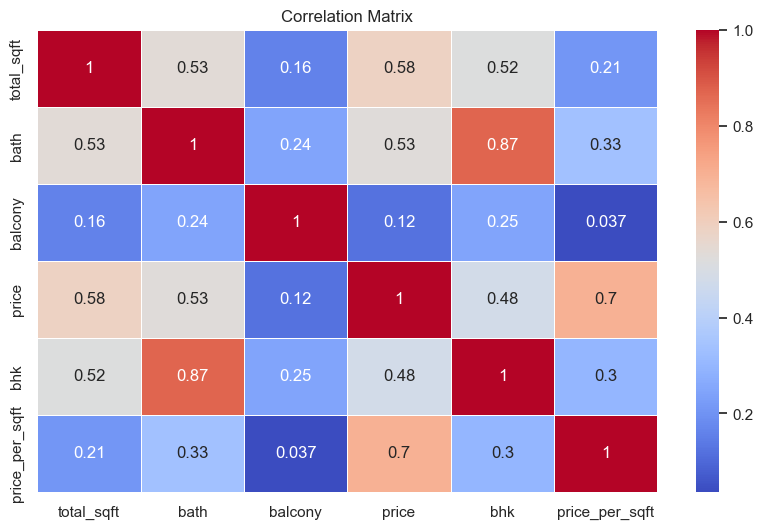

In [63]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

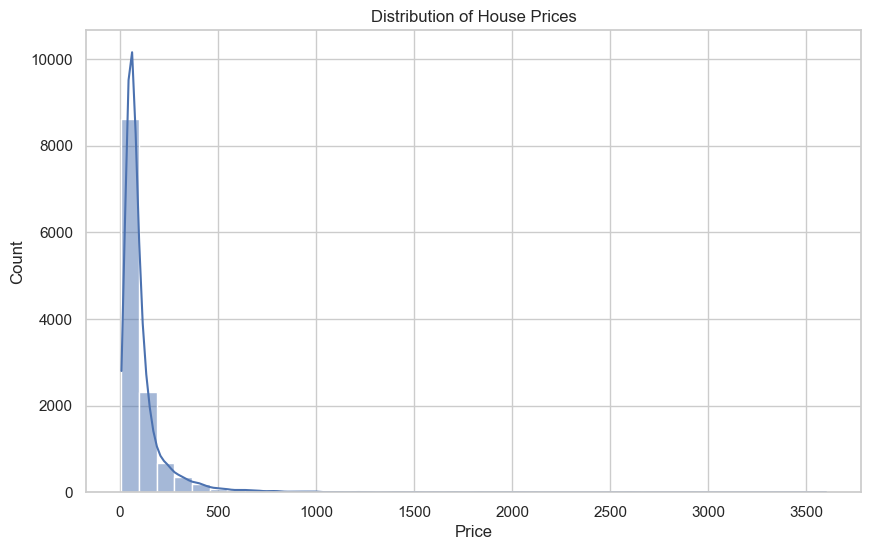

In [64]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=40)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

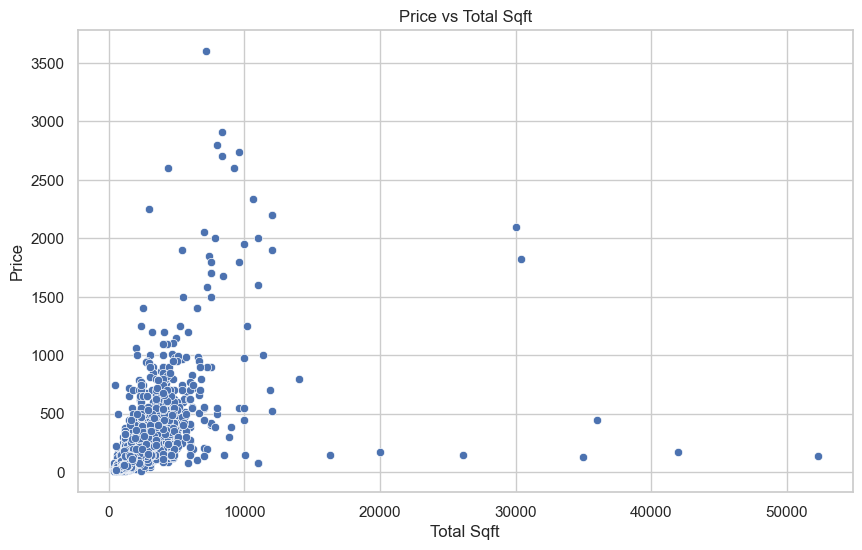

In [65]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_sqft', y='price', data=df)
plt.title("Price vs Total Sqft")
plt.xlabel("Total Sqft")
plt.ylabel("Price")
plt.show()

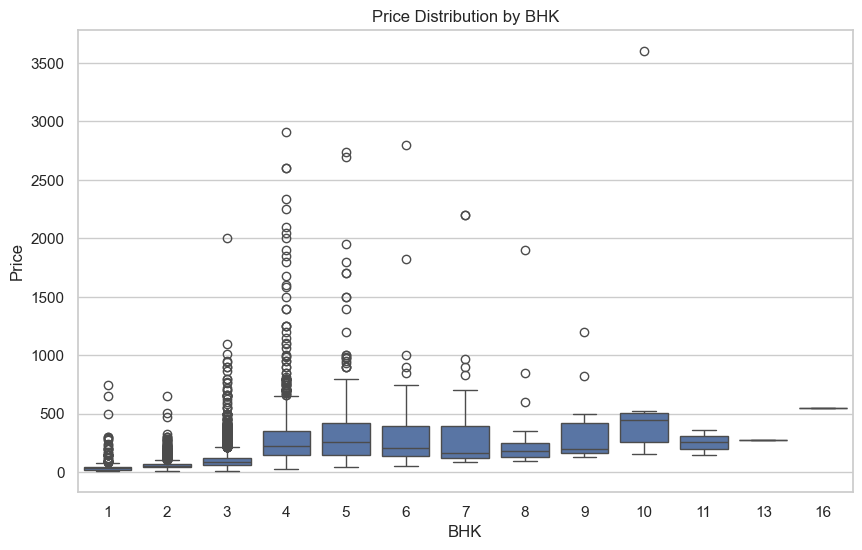

In [66]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='bhk', y='price', data=df)
plt.title("Price Distribution by BHK")
plt.xlabel("BHK")
plt.ylabel("Price")
plt.show()

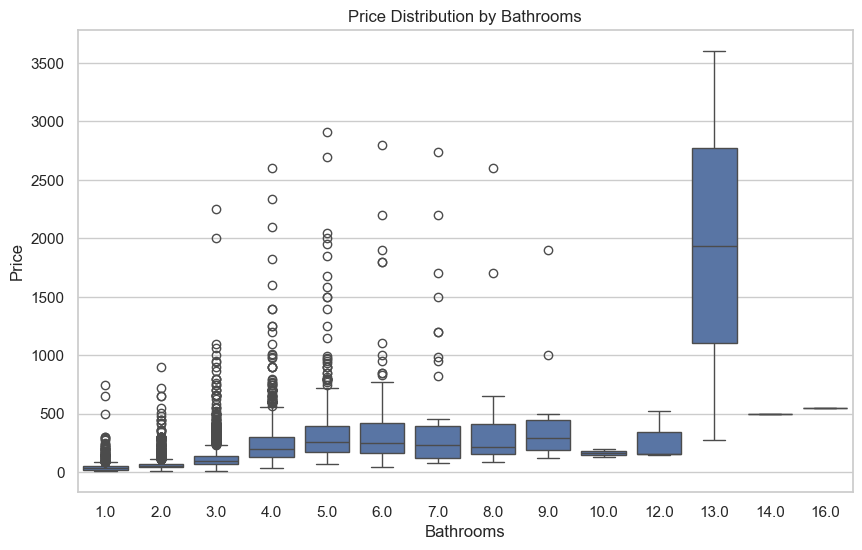

In [67]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='bath', y='price', data=df)
plt.title("Price Distribution by Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.show()

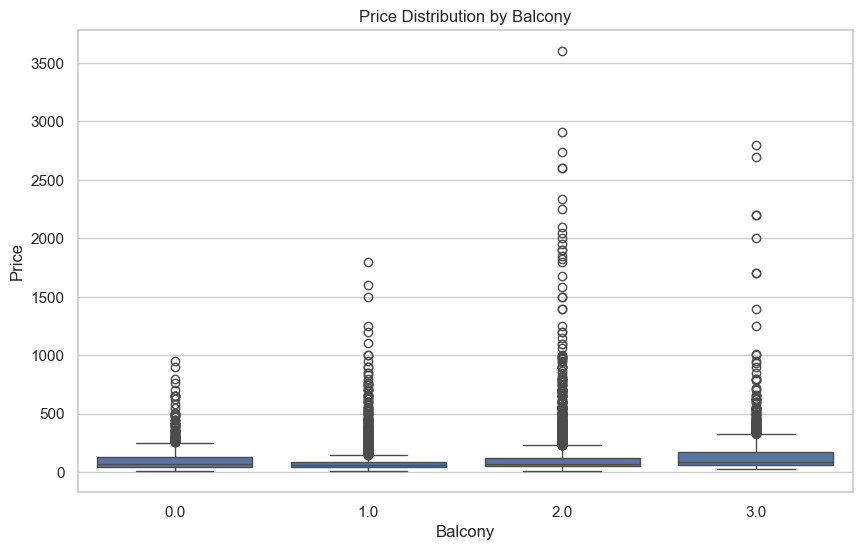

In [68]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='balcony', y='price', data=df)
plt.title("Price Distribution by Balcony")
plt.xlabel("Balcony")
plt.ylabel("Price")
plt.show()

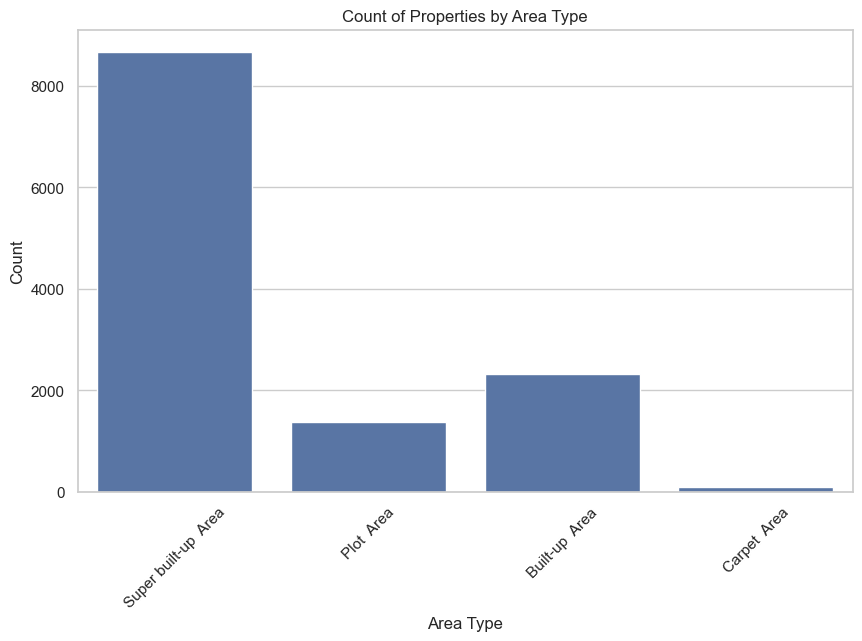

In [69]:
plt.figure(figsize=(10, 6))
sns.countplot(x='area_type', data=df)
plt.title("Count of Properties by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

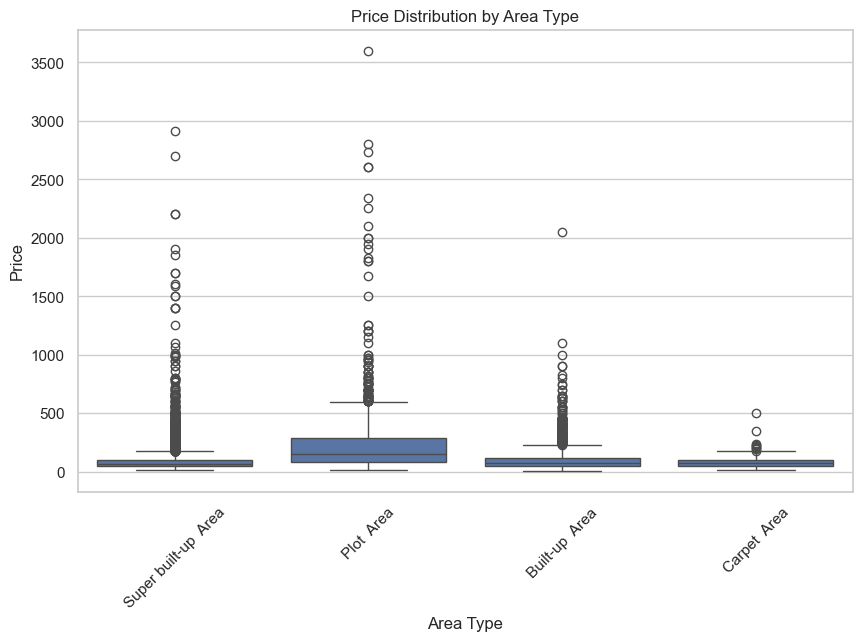

In [70]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='area_type', y='price', data=df)
plt.title("Price Distribution by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

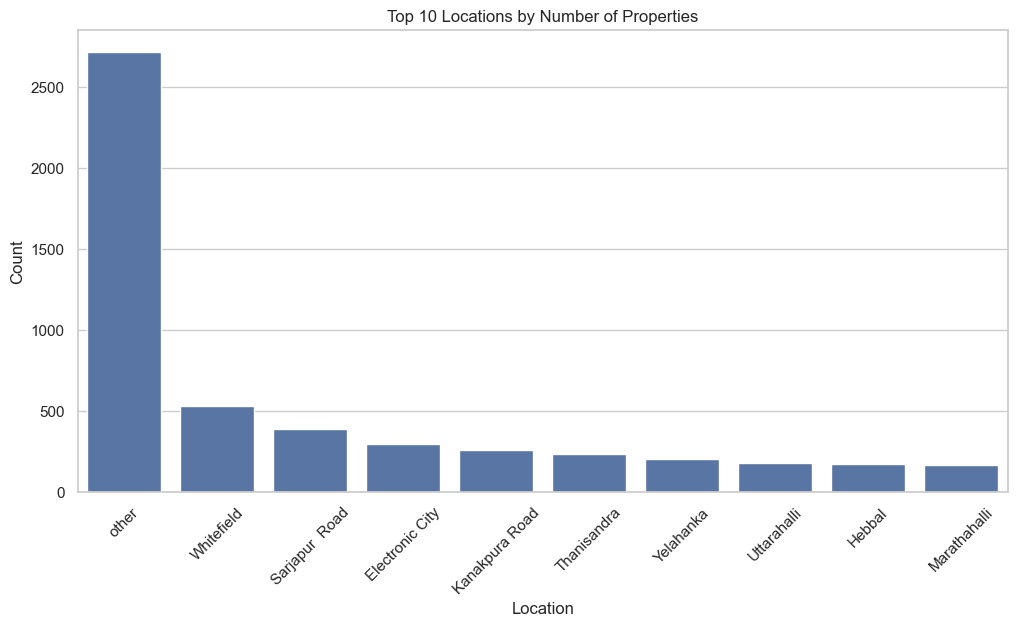

In [71]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_locations.index, y=top_locations.values)
plt.title("Top 10 Locations by Number of Properties")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

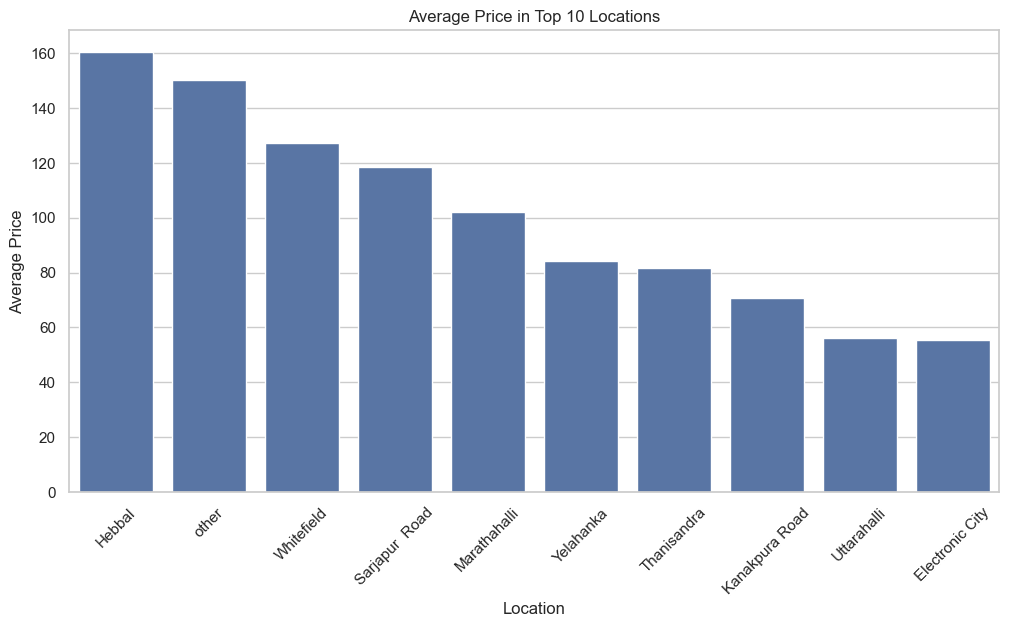

In [72]:
top_10_locations = df['location'].value_counts().head(10).index
avg_price_location = df[df['location'].isin(top_10_locations)].groupby('location')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_price_location.index, y=avg_price_location.values)
plt.title("Average Price in Top 10 Locations")
plt.xlabel("Location")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

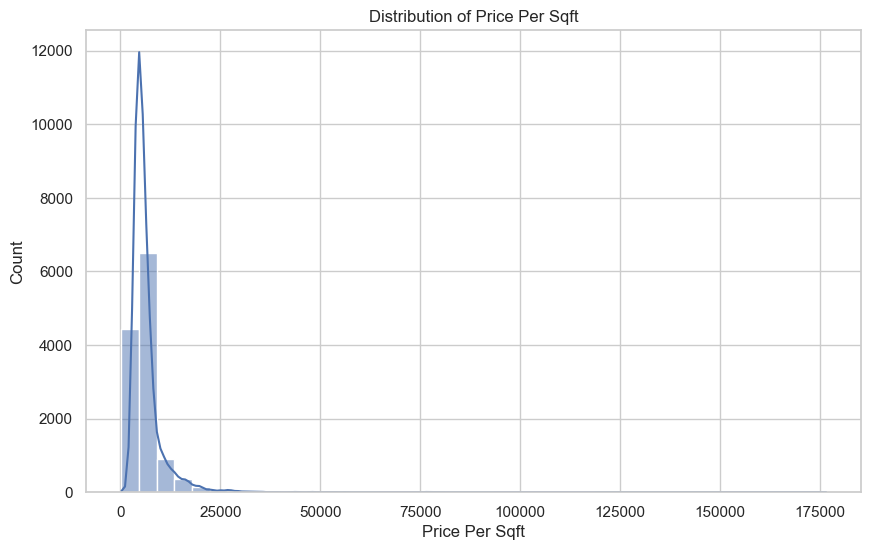

In [73]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price_per_sqft'], kde=True, bins=40)
plt.title("Distribution of Price Per Sqft")
plt.xlabel("Price Per Sqft")
plt.ylabel("Count")
plt.show()

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [75]:
# If df_model is not encoded yet, encode it first
df_encoded = pd.get_dummies(
    df_model,
    columns=['area_type', 'availability', 'location'],
    drop_first=True
)

X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

NameError: name 'df_model' is not defined

In [76]:
df_encoded = pd.get_dummies(
    df,
    columns=['area_type', 'availability', 'location'],
    drop_first=True
)

In [77]:
X = df_encoded.drop(['price', 'price_per_sqft'], axis=1)
y = df_encoded['price']

In [78]:
X = df_encoded.drop(
    ['price', 'price_per_sqft', 'sqft_per_bhk', 'bath_per_bhk'],
    axis=1,
    errors='ignore'
)

y = df_encoded['price']

In [79]:
df_encoded = pd.get_dummies(
    df,
    columns=['area_type', 'availability', 'location'],
    drop_first=True
)

X = df_encoded.drop(
    ['price', 'price_per_sqft', 'sqft_per_bhk', 'bath_per_bhk'],
    axis=1,
    errors='ignore'
)

y = df_encoded['price']

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [81]:
df.columns

Index(['area_type', 'availability', 'location', 'total_sqft', 'bath',
       'balcony', 'price', 'bhk', 'price_per_sqft'],
      dtype='object')

In [82]:
df_encoded = pd.get_dummies(
    df,
    columns=['area_type', 'availability', 'location'],
    drop_first=True
)

X = df_encoded.drop(['price', 'price_per_sqft'], axis=1)
y = df_encoded['price']

In [83]:
X.shape

(12456, 308)

In [84]:
y.shape

(12456,)

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [86]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2 Score": r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,44.954855,104.538349,0.552866
1,Decision Tree,37.476471,115.421683,0.454919
2,Random Forest,32.252187,94.272256,0.636375


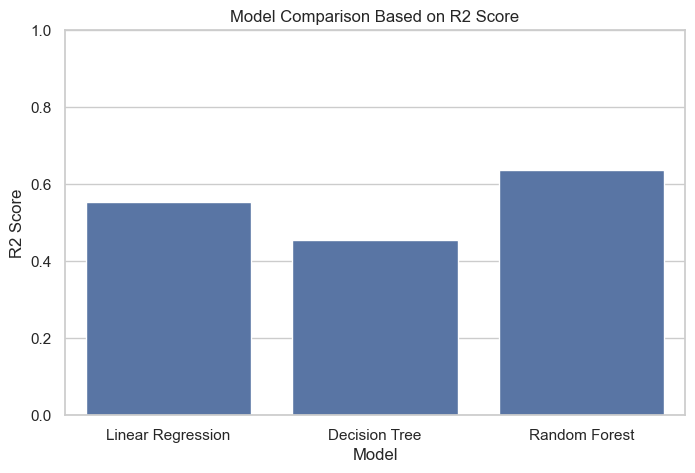

In [87]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='R2 Score', data=results_df)
plt.title('Model Comparison Based on R2 Score')
plt.ylim(0, 1)
plt.show()

In [88]:
best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 32.252186872547696
RMSE: 94.27225633782415
R2 Score: 0.6363748450760043


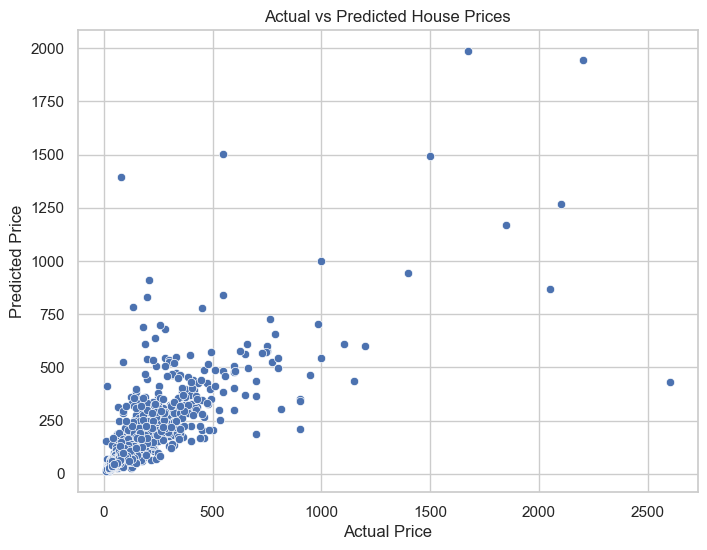

In [89]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [90]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

top_5_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(5)

top_5_features

,Feature,Importance
0,total_sqft,0.668599
1,bath,0.063838
3,bhk,0.048588
307,location_other,0.026886
2,balcony,0.026254


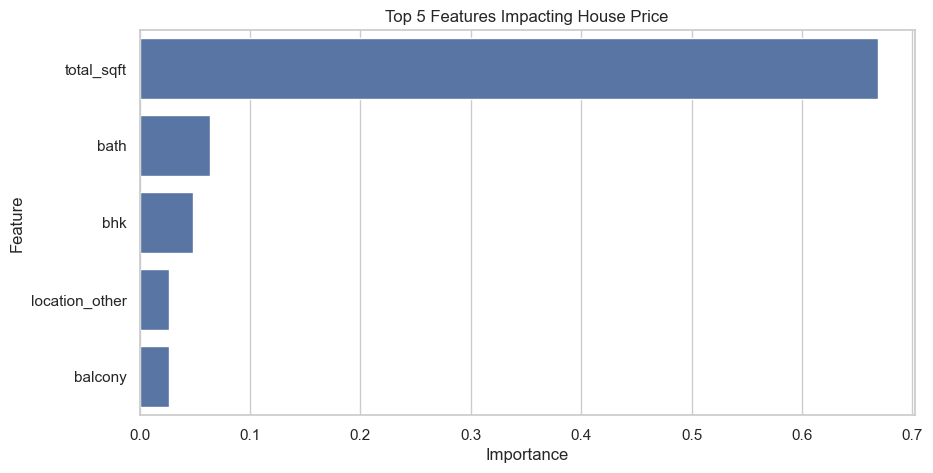

In [91]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=top_5_features)
plt.title("Top 5 Features Impacting House Price")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()